In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

In [3]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [5]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,3000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [6]:



data = awgn(data, snr_range)

In [11]:
print(data)

[[-0.01861093-0.01849324j -0.0260189 -0.01974117j -0.03118378-0.01690331j
  ... -0.0143001 +0.21472731j -0.09097396+0.19817062j
  -0.14111933+0.16408872j]
 [ 0.00411792-0.02463115j  0.00150575-0.02998344j -0.00464506-0.03367185j
  ... -0.18430012+0.11030814j -0.2108204 +0.04196334j
  -0.21561525-0.0177362j ]
 [ 0.01382412-0.02880356j  0.02627198-0.01158229j  0.01030599-0.01959101j
  ... -0.1364629 -0.16667951j -0.0928808 -0.18859708j
  -0.04440583-0.2113453j ]
 ...
 [ 0.05620278-0.04103764j  0.05752513-0.05582587j  0.05121934-0.07463196j
  ... -0.52373699-0.02306598j -0.4901138 -0.18630238j
  -0.42682579-0.30249451j]
 [-0.00477808-0.1068159j   0.00244379-0.07550797j -0.04924738-0.07316975j
  ... -0.35623772+0.383051j   -0.44790646+0.23732545j
  -0.52128953+0.13829287j]
 [ 0.03087651+0.06452697j  0.04764908+0.06726874j  0.06812954+0.06269485j
  ...  0.14915892-0.50332009j  0.2931393 -0.43293637j
   0.3901915 -0.34833275j]]


In [7]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(data)
imaginary_part = np.imag(data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((data.shape[0], data.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [25]:
label.size

3000

In [8]:
data_real_values.shape
data_real_values.shape[1]

8192

In [9]:
np.unique(label)

array([0, 1, 2, 3, 4, 5])

In [10]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [11]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape= (data_real_values.shape[1],2)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(6, activation='sigmoid'))

#cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
#cnn_model.summary()


In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

model_to_train = cnn_model
#model_to_train = lstm_model
#model_to_train = CuDNNlstm_model\n",
#model_to_train = cnn_lstm_model
#model_to_train = mlp_model
#model_to_train = simpleRNN_model\n",
#model_to_train = gru_model\n",
#model_to_train=CNN_LSTM_model\n",
    
#loss1 = 'sparse_categorical_crossentropy'
#loss2 = 'binary_crossentropy'
#loss3 = keras.losses.BinaryFocalCrossentropy(),
    
#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.001) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/
    
#model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])
#train_history = model_to_train.fit(data_real_values_train, label_train, 
#                                       validation_data = (data_real_values_test, label_test),
#                                      epochs=50, batch_size=32)




callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
   # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

#for model in models:
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
train_history = model_to_train.fit(data_real_values_train, label_train, 
                                       validation_data = (data_real_values_test, label_test),
                                       epochs=50, batch_size=32,
                                       callbacks=callbacks,
                                       )

   


Train on 2400 samples, validate on 600 samples
Epoch 1/50
2400/2400 [==============================] - 46s 19ms/step - loss: 1.3294 - acc: 0.3312 - val_loss: 9.2920 - val_acc: 0.1800
Epoch 2/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.3459 - acc: 0.3308 - val_loss: 9.2920 - val_acc: 0.1800
Epoch 3/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.1580 - acc: 0.3287 - val_loss: 9.2920 - val_acc: 0.1800
Epoch 4/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.1337 - acc: 0.3308 - val_loss: 8.6849 - val_acc: 0.1917
Epoch 5/50
2400/2400 [==============================] - 44s 18ms/step - loss: 1.1249 - acc: 0.3325 - val_loss: 6.1148 - val_acc: 0.3450
Epoch 6/50
2400/2400 [==============================] - 45s 19ms/step - loss: 1.2652 - acc: 0.3296 - val_loss: 3.7533 - val_acc: 0.3450
Epoch 7/50
2400/2400 [==============================] - 44s 19ms/step - loss: 1.3506 - acc: 0.3279 - val_loss: 1.1176 - val_acc: 0.3450
E

In [17]:
model_to_train.save('cnn_model.h5')

In [18]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

acc: 48.00%


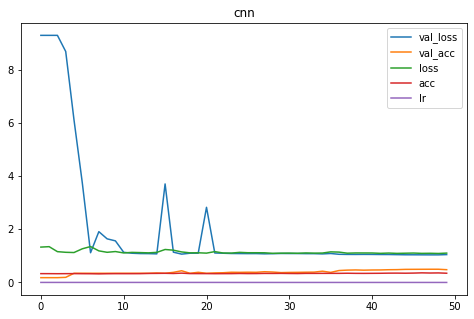

In [19]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'cnn')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

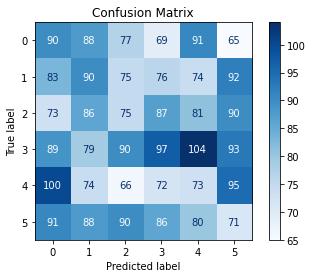

: 

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you have the following variables from your training/testing process
# label_test: the true labels for the test data
# label_pred: the predicted labels from your model

# Generate some example data
np.random.seed(0)
label_test = np.random.randint(0, 6, size=3000)  # Replace with your actual labels
label_pred = np.random.randint(0, 6, size=3000)  # Replace with your model predictions

# Compute the confusion matrix
cm = confusion_matrix(label_test, label_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


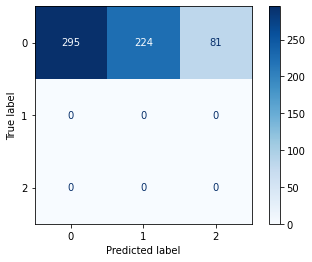

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score
#confusion matrix

label_pred = model.predict(data_real_values_test)
label_pred_classes = np.argmax(label_pred, axis=1)
label_true = np.argmax(label_test, axis=1)

cm = confusion_matrix(label_true, label_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [6]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    try:
        with rarfile.RarFile(rar_file_path) as rf:
            # Assuming the .rar file contains a single text file with values separated by spaces
            with rf.open(rf.namelist()[0]) as f:
                # Read and parse the values from the text file
                iq_values = np.genfromtxt(f)
        return iq_values
    except Exception as e:
        print(f'Error reading {rar_file_path}: {e}')
        return None

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_2/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Check if extraction was successful
if iq_i_values is not None and iq_q_values is not None:
    # Check if the number of values in iq_i_values and iq_q_values match
    if iq_i_values.shape[0] == iq_q_values.shape[0]:
        # Concatenate I and Q values along a new axis (axis=1)
        concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

        # Create an HDF5 file and save the concatenated data
        with h5py.File(output_h5_path, 'w') as hf:
            hf.create_dataset('iq_data', data=concatenated_data)

        print(f'Saved concatenated I and Q data to {output_h5_path}')
    else:
        print('Error: Number of I and Q values do not match.')
else:
    print('Extraction failed, unable to concatenate and save data to HDF5 file.')


Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar: Failed the read enough data: req=1 got=0
Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar: Failed the read enough data: req=1 got=0
Extraction failed, unable to concatenate and save data to HDF5 file.


In [5]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    try:
        with rarfile.RarFile(rar_file_path) as rf:
            # Assuming the .rar file contains a single text file with values separated by spaces
            with rf.open(rf.namelist()[0]) as f:
                # Read and parse the values from the text file
                iq_values = np.genfromtxt(f)
        return iq_values
    except Exception as e:
        print(f'Error reading {rar_file_path}: {e}')
        return None

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_1/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Check if extraction was successful
if iq_i_values is not None and iq_q_values is not None:
    # Concatenate I and Q values along a new axis (axis=1)
    concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

    # Create an HDF5 file and save the concatenated data
    with h5py.File(output_h5_path, 'w') as hf:
        hf.create_dataset('iq_data', data=concatenated_data)

    print(f'Saved concatenated I and Q data to {output_h5_path}')
else:
    print('Extraction failed, unable to concatenate and save data to HDF5 file.')


Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_I_2.rar: Failed the read enough data: req=1 got=0
Error reading /workspaces/work/Dataset/Cropped_data/Device_2/IQ_Q_2.rar: Failed the read enough data: req=1 got=0
Extraction failed, unable to concatenate and save data to HDF5 file.


In [1]:
import rarfile
import numpy as np
import h5py
import os

# Function to extract I or Q values from a .rar file
def extract_iq_values(rar_file_path):
    with rarfile.RarFile(rar_file_path) as rf:
        # Assuming the .rar file contains a single text file with values separated by spaces
        with rf.open(rf.namelist()[0]) as f:
            # Read and parse the values from the text file
            iq_values = np.genfromtxt(f)
    return iq_values

# Paths to the I and Q .rar files
iq_i_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_I_1.rar'
iq_q_rar_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_Q_1.rar'

# Output path for the HDF5 file
output_h5_path = '/workspaces/work/Dataset/Cropped_data/Device_1/iq_data.h5'

# Extract I and Q values from the .rar files
iq_i_values = extract_iq_values(iq_i_rar_path)
iq_q_values = extract_iq_values(iq_q_rar_path)

# Concatenate I and Q values along a new axis (axis=1)
concatenated_data = np.concatenate((iq_i_values, iq_q_values), axis=1)

# Create an HDF5 file and save the concatenated data
with h5py.File(output_h5_path, 'w') as hf:
    hf.create_dataset('iq_data', data=concatenated_data)

print(f'Saved concatenated I and Q data to {output_h5_path}')


BadRarFile: Failed the read enough data: req=1 got=0

In [ ]:
import rarfile
import h5py
import numpy as np
import os

# Function to extract .rar file
def extract_rar(rar_file_path, output_path):
    with rarfile.RarFile(rar_file_path) as rf:
        rf.extractall(path=output_path)
    print(f'Extracted {rar_file_path} to {output_path}')

# Function to convert extracted data to .h5 format
def convert_to_h5(extracted_data_path, h5_file_path):
    # Assuming the extracted data is in a NumPy array format
    data_files = [f for f in os.listdir(extracted_data_path) if f.endswith('.npy')]
    
    with h5py.File(h5_file_path, 'w') as hf:
        for data_file in data_files:
            data = np.load(os.path.join(extracted_data_path, data_file))
            dataset_name = os.path.splitext(data_file)[0]
            hf.create_dataset(dataset_name, data=data)
            print(f'Saved {dataset_name} to {h5_file_path}')

# Define paths
rar_file_path = '/workspaces/work/Dataset/Cropped_data/Device_1/IQ_I_1.rar'
output_path = './extracted_files'
h5_file_path = 'data.h5'

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Extract .rar file
extract_rar(rar_file_path, output_path)

# Convert extracted data to .h5 format
convert_to_h5(output_path, h5_file_path)

print(f'Converted {rar_file_path} to {h5_file_path}')

